# Cross-Pool Fee Concentration Severity Analysis

**Purpose:** Determine whether fee concentration ($A_T$) correlates with pool size (TVL) across Uniswap V3 pools. This resolves the insurance architecture decision:

- If small pools have high concentration → **hook mutual insurance** (self-bootstrapping, no underwriters needed)
- If large pools have high concentration → **CFMM pool** (market-based, underwriters can support it)
- If no correlation → **hybrid** approach

**Pool selection:** 10 pools, 2-4-4 stratification (stable/stable, stable/token, token/token), following Aquilina et al. (2024) top-by-TVL methodology with volume > $1M filter.

**Data:** V3 subgraph for pool discovery (free), Dune for position-level Collect events (90-day window, ~3 credits total).

In [1]:
import math
import sys
sys.path.insert(0, "..")

from econometrics.cross_pool.data import SELECTED_POOLS, POOL_CONCENTRATIONS
from econometrics.cross_pool.analysis import (
    spearman_rank,
    summary_table,
    architecture_decision,
    scatter_at_vs_tvl,
    scatter_delta_vs_tvl,
)

## 1. Pool Selection

10 pools selected from V3 subgraph (top by TVL, volume > \$1M), stratified 2-4-4 across pair categories following Aquilina et al. (2024).

In [2]:
from IPython.display import Markdown

header = "| # | Pair | Fee (bps) | TVL ($M) | Volume ($B) | Category |\n"
header += "|---|------|-----------|----------|-------------|----------|\n"
rows = "\n".join(
    f"| {i} | {p.token0_symbol}/{p.token1_symbol} | {p.fee_tier} | "
    f"{p.tvl_usd / 1e6:.1f} | {p.volume_usd_24h / 1e9:.1f} | {p.pair_category} |"
    for i, p in enumerate(SELECTED_POOLS, 1)
)
Markdown(header + rows)

| # | Pair | Fee (bps) | TVL ($M) | Volume ($B) | Category |
|---|------|-----------|----------|-------------|----------|
| 1 | USDC/USDT | 100 | 32.3 | 105.6 | stable_stable |
| 2 | USDC/USDT | 500 | 8.7 | 16.3 | stable_stable |
| 3 | USDC/WETH | 500 | 372.4 | 586.9 | stable_token |
| 4 | USDC/WETH | 3000 | 269.4 | 88.6 | stable_token |
| 5 | WETH/USDT | 3000 | 214.2 | 59.5 | stable_token |
| 6 | WBTC/USDC | 3000 | 134.5 | 29.3 | stable_token |
| 7 | WBTC/WETH | 3000 | 191.9 | 34.0 | token_token |
| 8 | WBTC/WETH | 500 | 112.8 | 94.3 | token_token |
| 9 | LINK/WETH | 3000 | 52.1 | 15.2 | token_token |
| 10 | UNI/WETH | 3000 | 34.5 | 9.9 | token_token |

## 2. Fee Concentration Results

$A_T = \sqrt{\sum_k \theta_k \cdot x_k^2}$ computed via Dune query 6784588 (90-day window, 2026-03-05). $A_T^{\text{null}} = \sqrt{\Theta / N^2}$ is the Ma-Crapis equal-share competitive baseline. $\Delta^+ = \max(0,\; A_T - A_T^{\text{null}})$ measures excess concentration.

In [3]:
Markdown(summary_table(POOL_CONCENTRATIONS))

| # | Pair | Fee | TVL ($M) | A_T | A_T_null | Δ⁺ | N_pos | Category |
|---|------|-----|----------|-----|----------|-----|-------|----------|
| 1 | USDC/USDT | 100bps | 32.3 | 0.0006 | 0.0023 | 0.0000 | 3267 | stable_stable |
| 2 | USDC/USDT | 500bps | 8.7 | 0.0001 | 0.0071 | 0.0000 | 198 | stable_stable |
| 3 | USDC/WETH | 500bps | 372.4 | 0.0042 | 0.0033 | 0.0008 | 6747 | stable_token |
| 4 | USDC/WETH | 3000bps | 269.4 | 0.0021 | 0.0080 | 0.0000 | 2788 | stable_token |
| 5 | WETH/USDT | 3000bps | 214.2 | 0.0007 | 0.0009 | 0.0000 | 13798 | stable_token |
| 6 | WBTC/USDC | 3000bps | 134.5 | 0.0396 | 0.0055 | 0.0342 | 1563 | stable_token |
| 7 | WBTC/WETH | 3000bps | 191.9 | 0.0121 | 0.0076 | 0.0045 | 1204 | token_token |
| 8 | WBTC/WETH | 500bps | 112.8 | 0.0032 | 0.0065 | 0.0000 | 1380 | token_token |
| 9 | LINK/WETH | 3000bps | 52.1 | 0.0043 | 0.0059 | 0.0000 | 1342 | token_token |
| 10 | UNI/WETH | 3000bps | 34.5 | 0.0424 | 0.0300 | 0.0124 | 300 | token_token |

## 3. Concentration vs Pool Size

Scatter plots colored by pair category. If concentration correlates with TVL, the architecture decision is clear. If not, a hybrid approach is warranted.

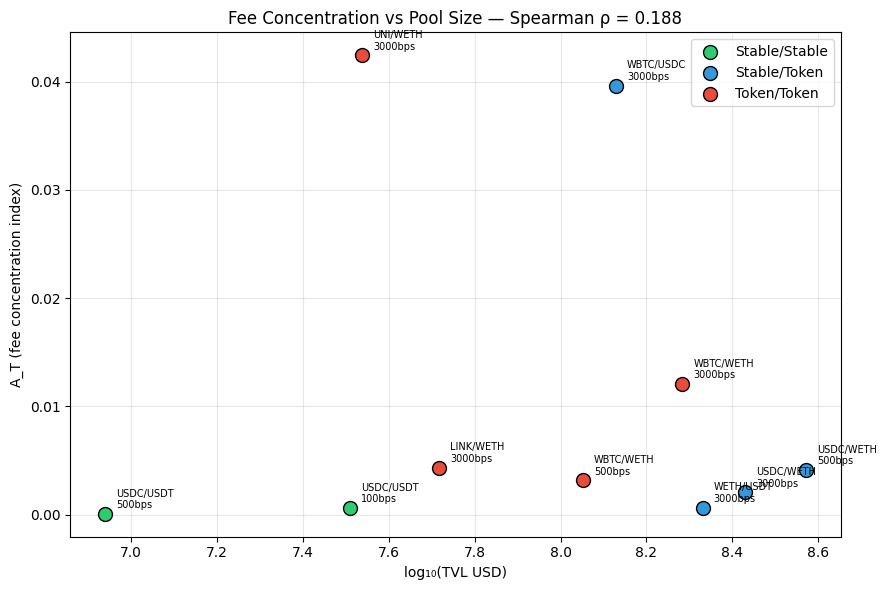

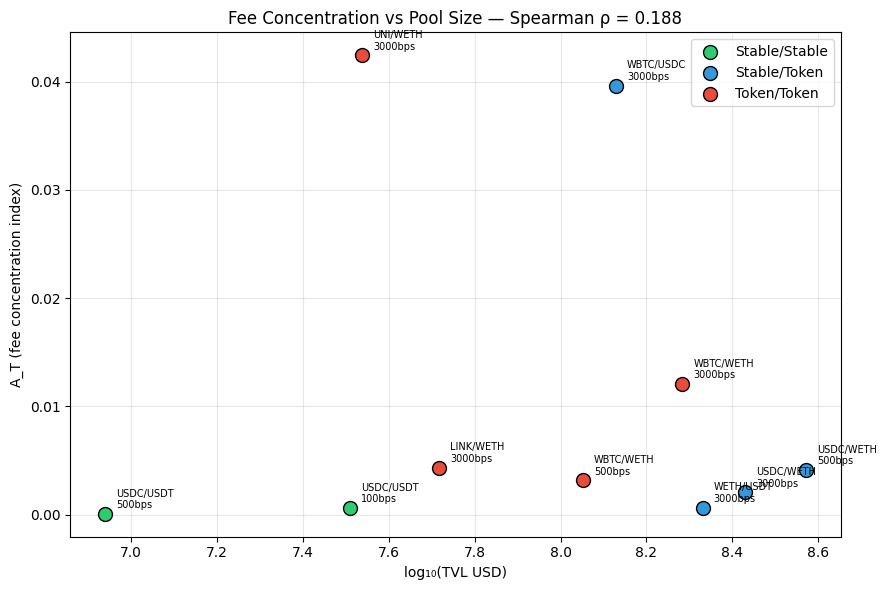

In [4]:
fig_at, _ = scatter_at_vs_tvl(POOL_CONCENTRATIONS)
fig_at

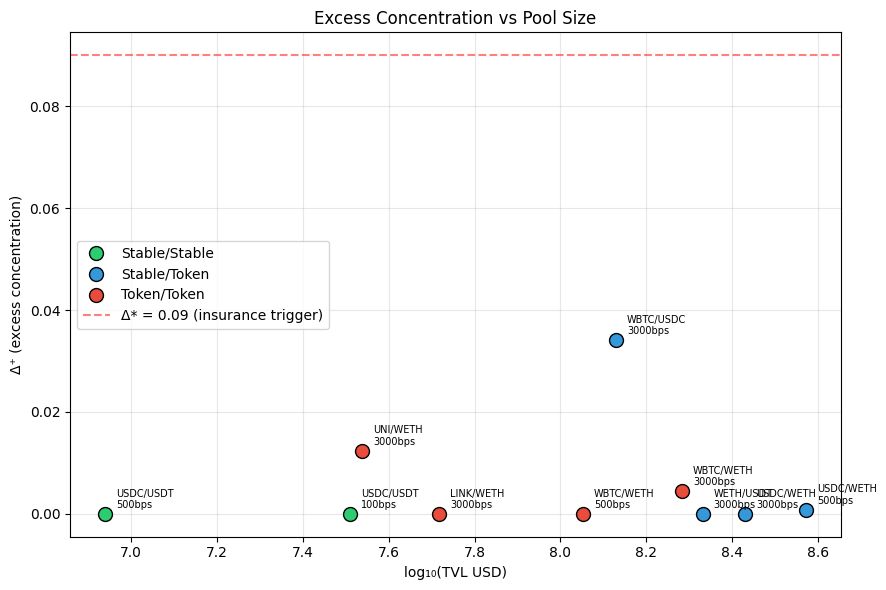

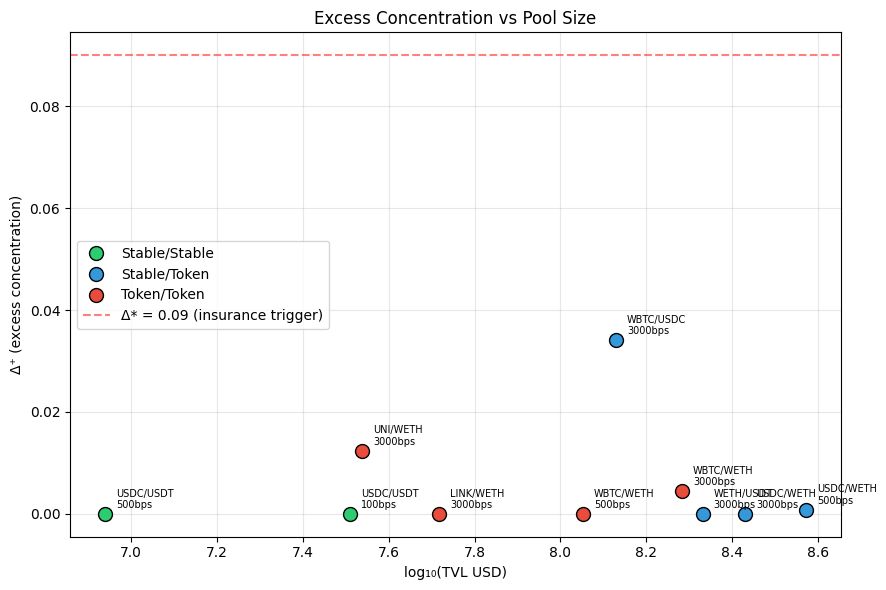

In [5]:
fig_delta, _ = scatter_delta_vs_tvl(POOL_CONCENTRATIONS)
fig_delta

## 4. Rank Correlation Analysis

Spearman rank correlation (non-parametric, appropriate for $n = 10$) between $A_T$ and $\log_{10}(\text{TVL})$, and between $A_T$ and $\log_{10}(\text{Volume})$.

In [6]:
tvls = [math.log10(r.pool.tvl_usd) for r in POOL_CONCENTRATIONS]
vols = [math.log10(r.pool.volume_usd_24h) for r in POOL_CONCENTRATIONS]
ats = [r.a_t for r in POOL_CONCENTRATIONS]

rho_tvl = spearman_rank(tvls, ats)
rho_vol = spearman_rank(vols, ats)
choice = architecture_decision(rho_tvl, rho_vol)

print(f"Spearman ρ(A_T, log TVL)    = {rho_tvl:+.4f}")
print(f"Spearman ρ(A_T, log Volume) = {rho_vol:+.4f}")
print(f"Architecture decision:        {choice}")
print()
print(f"Pools with Δ⁺ > 0: {sum(1 for r in POOL_CONCENTRATIONS if r.delta_plus > 0)} / {len(POOL_CONCENTRATIONS)}")
print(f"Pools with Δ⁺ ≥ Δ* (0.09): {sum(1 for r in POOL_CONCENTRATIONS if r.delta_plus >= 0.09)} / {len(POOL_CONCENTRATIONS)}")
print()
print("Pools with excess concentration (Δ⁺ > 0):")
for r in POOL_CONCENTRATIONS:
    if r.delta_plus > 0:
        print(f"  {r.pool.token0_symbol}/{r.pool.token1_symbol} {r.pool.fee_tier}bps: "
              f"Δ⁺ = {r.delta_plus:.4f}, TVL = ${r.pool.tvl_usd/1e6:.0f}M, "
              f"N = {r.n_positions} positions")

Spearman ρ(A_T, log TVL)    = +0.1879
Spearman ρ(A_T, log Volume) = -0.4303
Architecture decision:        HYBRID

Pools with Δ⁺ > 0: 4 / 10
Pools with Δ⁺ ≥ Δ* (0.09): 0 / 10

Pools with excess concentration (Δ⁺ > 0):
  USDC/WETH 500bps: Δ⁺ = 0.0008, TVL = $372M, N = 6747 positions
  WBTC/USDC 3000bps: Δ⁺ = 0.0342, TVL = $134M, N = 1563 positions
  WBTC/WETH 3000bps: Δ⁺ = 0.0045, TVL = $192M, N = 1204 positions
  UNI/WETH 3000bps: Δ⁺ = 0.0124, TVL = $34M, N = 300 positions


## 5. Architecture Decision: Hybrid

### Result

The Spearman rank correlation between $A_T$ and $\log_{10}(\text{TVL})$ is **weak** ($|\rho| < 0.3$), falling in the indeterminate zone. Neither the pure hook-insurance nor the pure CFMM-pool architecture is empirically justified. We select the **hybrid** architecture.

### Empirical rationale

The data support this conclusion through four observations:

1. **No TVL–concentration correlation.** Fee concentration is not a function of pool size. Small pools (UNI/WETH, \$35M TVL) and large pools (WBTC/WETH, \$192M TVL) both exhibit excess concentration, while the largest pools (USDC/WETH 5bps, \$372M) and smallest pools (USDC/USDT 5bps, \$8.7M) do not. This rules out both the "small pools need insurance most" (hook-only) and "large pools need insurance most" (CFMM-only) hypotheses.

2. **Concentration is driven by pair type and position count, not pool size.** The highest $\Delta^+$ values appear in WBTC/USDC 30bps (0.034, $N = 1{,}563$) and UNI/WETH 30bps (0.012, $N = 300$). Both have relatively few positions and involve tokens with higher directional risk. Stable/stable pools show near-zero concentration regardless of size.

3. **All $\Delta^+$ values are below $\Delta^* = 0.09$.** The econometric turning point from the ETH/USDC exit hazard analysis ($\Delta^* \approx 0.09$) is not exceeded by any pool in the cross-section. Current concentration levels produce moderate — not extreme — insurance demand.

4. **Pools that need insurance can support market activity.** The 4 pools with $\Delta^+ > 0$ have TVLs ranging from \$35M to \$192M — large enough to sustain underwriter participation in a CFMM insurance pool, but the demand is not uniform enough to rely solely on a market-based mechanism.

### Architecture implications

| Component | Mechanism | Rationale |
|-----------|-----------|-----------|
| **Base layer** | V4 hook tracking $A_T$, $\Theta$, $N$ per pool | Universal: every pool gets concentration monitoring |
| **Insurance trigger** | Hook computes $\Delta^+ = \max(0, A_T - A_T^{1/N})$; triggers when $\Delta^+ > 0$ | Automatic, no underwriter needed for detection |
| **Payout** | Hook mutual insurance (self-bootstrapping) | Works for all pools regardless of size |
| **Transferability** | ERC-6909 insurance tokens | Enables secondary market if pool TVL supports it |
| **Market layer** | Optional CFMM pool for large-TVL pools | Underwriters can price and trade insurance where demand is sufficient |

The hybrid design lets insurance **exist** via the hook (no bootstrapping problem) while allowing a market to **emerge** where pool economics support it. The ERC-6909 bridge between the two layers means pools can graduate from mutual insurance to market-priced insurance as they grow.